In [ ]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint


from network import NetCNN1D, NetCNN2D_CSP, build_functional_cnn2D

from mne.decoding import CSP
from sklearn.model_selection import StratifiedKFold,  StratifiedShuffleSplit

import numpy as np
import sys, os

import dataset_NewEEG
from config import Config

import matplotlib.pyplot as plt


import pandas as pd
import pickle
import tqdm, logging, warnings

import train_evaluate


from skimage import exposure



# Filter out info and warnings from TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger('tensorflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')


config = Config()




# Choose from: 'CLeft', 'CRight', 'CUp' and 'CDown'
config.used_classes = [['CLeft'], ['CRight']]
config.session_type = 'S2'


config.test_session = 9 # 3, 7, 9


config.t_start = 0 
config.t_end = 3.0

config.window_size = 2.0




config.n_csp_components = 3


# All available channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']
config.used_channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']

config.model_type == '2D'




################# Changed in Adaptation #################


config.epochs = 700 # 100
config.batch_size = 32

config.stride = 0.5

config.n_splits = 5
config.val_size = 0.2


config.learning_rate = 2e-4 #2e-4
config.label_smoothing = 0.05
config.weight_decay = 2e-5

In [2]:
from keras.utils import get_custom_objects

get_custom_objects()['NetCNN2D_CSP'] = NetCNN2D_CSP



model = tf.keras.models.load_model(os.path.join('saved_models', 'best_model.tf'))

with open(os.path.join('saved_models', 'csp.pkl'), 'rb') as f:
    csp_trained = pickle.load(f)

In [3]:
X, y = dataset_NewEEG.session_dataset(config, f'I{config.test_session:02d}')
X, y = dataset_NewEEG.slice_EEG_epoch(config, X, y)


X = csp_trained.transform(X)


# Reshape input depending on model, 2D or 1D convs
if config.model_type == '2D':
    X = np.expand_dims(X, 3)

else:
    X = X.transpose(0, 2, 1)


y = tf.keras.utils.to_categorical(y, num_classes = len(config.used_classes))



# Linear Quantization
Xq = ((X - X.min()) / (X.max() - X.min()) * 255).astype(np.uint8)

# Non Linear Quantization: Histogram Equalization 
X_norm = (X - X.min()) / (X.max() - X.min())
X_eq = exposure.equalize_hist(X_norm)

Xq_hist = (X_eq * 255).astype(np.uint8)

Text(0.5, 1.0, 'Non Linear Q X')

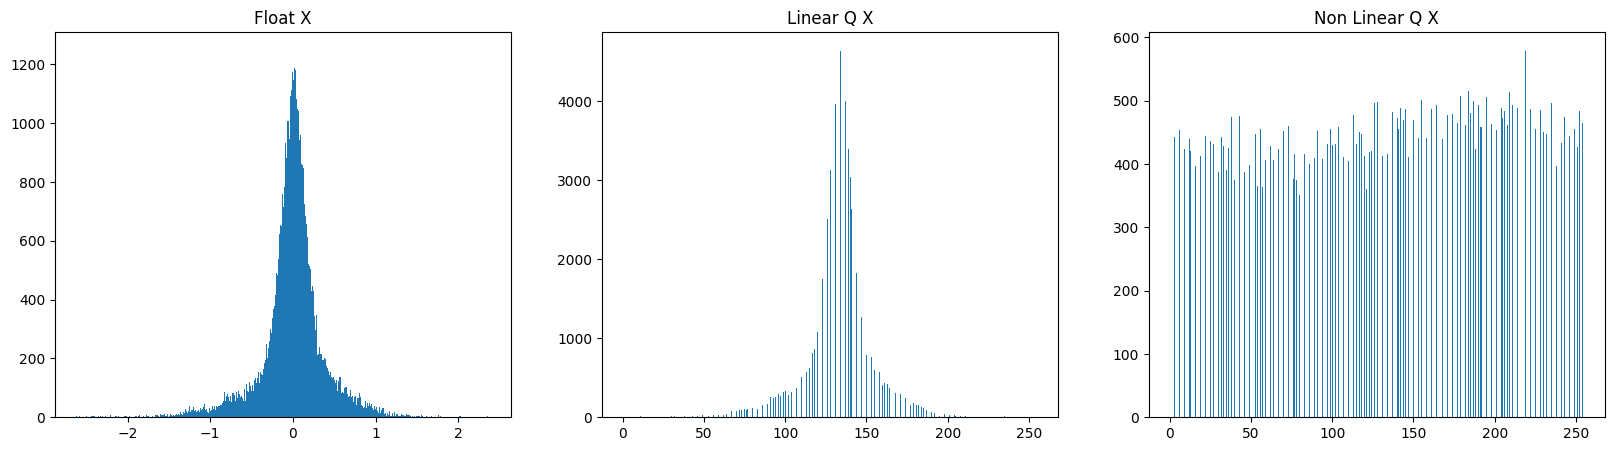

In [4]:
plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
_ = plt.hist(X.flatten(), bins=1000)
plt.title("Float X")

plt.subplot(1,3,2)
_ = plt.hist(Xq.flatten(), bins=1000)
plt.title("Linear Q X")

plt.subplot(1,3,3)
_ = plt.hist(Xq_hist.flatten(), bins=1000)
plt.title("Non Linear Q X")

In [10]:
class NetCNN2D_CSP(keras.Model):
    '''
        Simple conv model for testing purposes
    '''
    def __init__(self, n_classes, **kwargs):
        super().__init__(**kwargs)

        self.n_classes = n_classes

        self.fc = keras.Sequential( 
            [ 
                keras.layers.Flatten(),
                keras.layers.Dense(128),
                keras.layers.ReLU(max_value=1000.0),
                keras.layers.Dropout(0.1),
                keras.layers.Dense(n_classes)

            ], name = 'fc')
        

        #self.model = keras.Sequential([self.cnn1, self.cnn2, self.gap, self.fc])


    def call(self, x):

        temp = self.fc(x)
        
        #temp = self.model(x)
        
        return temp
    

    def get_config(self):
        config = super().get_config()
        config.update({
            'n_classes': self.n_classes,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)
    



def build_functional_cnn2D(n_classes, input_shape):
    inputs = tf.keras.Input(shape=input_shape)
    
    # FC
    x = tf.keras.layers.Flatten()(inputs)
    x = tf.keras.layers.Dense(128)(x)
    x = tf.keras.layers.ReLU(max_value=1000.0)(x)
    x = tf.keras.layers.Dropout(0.1)(x)
    outputs = tf.keras.layers.Dense(n_classes)(x)
    
    functional_model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return functional_model

In [12]:
functional_model = build_functional_cnn2D(n_classes=2, input_shape=(3, 100))
#functional_model.set_weights(model.get_weights())

In [ ]:
from quantizeml.models import QuantizationParams, quantize

#model.build((8, 9, 312, 1))

qparams = QuantizationParams(input_weight_bits=8, weight_bits=4, activation_bits=4, per_tensor_activations=True)
quantized_model = quantize(functional_model, qparams=qparams, samples=Xq, num_samples=120, batch_size=16, epochs=5)
quantized_model.summary()

TypeError: Exception encountered when calling layer "flatten_4" (type QuantizedFlatten).

in user code:

    File "c:\Users\Hammo\OneDrive\Desktop\Neurobus\eh-venv\lib\site-packages\quantizeml\layers\layers_base.py", line 204, in check_inputs  *
        raise TypeError(f"{self.__class__.__name__} only accepts {supported} inputs. "

    TypeError: QuantizedFlatten only accepts [<class 'quantizeml.tensors.fixed_point.FixedPoint'>] inputs. Receives <class 'tensorflow.python.framework.ops.SymbolicTensor'> inputs.


Call arguments received by layer "flatten_4" (type QuantizedFlatten):
  • inputs=tf.Tensor(shape=(None, 3, 100), dtype=uint8)

In [8]:
quantized_model.compile(
            loss= CategoricalCrossentropy(from_logits=True, label_smoothing=config.label_smoothing),
            optimizer=keras.optimizers.Adam(learning_rate=config.learning_rate, weight_decay = config.weight_decay), 
            metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
    ) 

quantized_model.evaluate(X, y)

3/3 [==============================] - 3s 7ms/step - loss: 87.0487 - acc: 0.4667


[87.04871368408203, 0.46666666865348816]

In [9]:
import akida
from cnn2snn import convert, set_akida_version, AkidaVersion


virtual_chip = akida.AKD1000()



with set_akida_version(AkidaVersion.v1):
    model_akida = convert(quantized_model)
    model_akida.summary()

                Model Summary                 
______________________________________________
Input shape  Output shape  Sequences  Layers
[3, 500, 1]  [1, 1, 2]     1          4     
______________________________________________

_______________________________________________________
Layer (type)           Output shape  Kernel shape    

============ SW/conv2d_4-dense_5 (Software) ===========

conv2d_4 (InputConv.)  [3, 72, 8]    (3, 11, 1, 8)   
_______________________________________________________
conv2d_5 (Conv.)       [3, 15, 16]   (3, 7, 8, 16)   
_______________________________________________________
dense_4 (Fully.)       [1, 1, 128]   (1, 1, 720, 128)
_______________________________________________________
dense_5 (Fully.)       [1, 1, 2]     (1, 1, 128, 2)  
_______________________________________________________


In [10]:
model_akida.map(virtual_chip)

In [11]:
model_akida.sequences[0]

<akida.Sequence, name=SW/conv2d_4-conv2d_5, backend=Software, passes=[<akida.Pass, layers=[<akida.Layer, type=LayerType.InputConvolutional, name=conv2d_4, input_dims=[3, 500, 1], output_dims=[3, 72, 8]>, <akida.Layer, type=LayerType.Convolutional, name=conv2d_5, input_dims=[3, 72, 8], output_dims=[3, 15, 16]>]>]>

In [12]:
print(len(model_akida.sequences))
# Assume there is at least one sequence.
sequence = model_akida.sequences[0]
# Check program size
print(len(sequence.program))

2


TypeError: object of type 'NoneType' has no len()

In [13]:
model_akida.forward(Xq)

RuntimeError: An actual hardware device is required.